In [6]:
%load_ext autoreload
%autoreload 2

%aimport -torch
%aimport -numpy
%aimport -qiskit
%aimport -pennylane
%aimport -ray
%aimport -sklearn

from pathlib import Path
import tempfile
import os
from functools import partial

# These import from Data folder are necessary for pickle load to work
from Data.Primitives.environment_classes import Drone, Radar, Context
from Data.Primitives.noise_models import AdditiveWhiteGaussianNoise
from Data.Primitives.presets import *
from Data.Generators.synthetic_dataset_generator import DatasetMetadata, DataRequest

from MachineLearning.Preprocessing.file_loader import SyntheticDataFileLoader
from MachineLearning.Preprocessing.frequency_domain_parser import FrequencyDomainDataParser
from MachineLearning.Preprocessing.time_domain_parser import TimeDomainDataParser
from MachineLearning.Torch_datasets.synthetic_time_dataset import SyntheticTimeDomainRadarDataset
from MachineLearning.Torch_datasets.synthetic_frequency_dataset import SyntheticFrequencyDomainRadarDataset
from MachineLearning.Models.experiment_pure.classical_neural_network import ClassicalNeuralNetwork
from MachineLearning.Models.experiment_pure.quantum_neural_network import QuantumNeuralNetwork

from matplotlib import pyplot as plt
import numpy as np

from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


import torch
from torch import nn
from torch.nn.functional import normalize
from torch.utils.data import DataLoader
from torch.optim import SGD

import ray
from ray import tune
from ray.tune import Checkpoint
from ray.tune.schedulers import ASHAScheduler

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
PROJECT_ROOT = Path().cwd().parent
ray.shutdown()
ctx = ray.init(runtime_env={
    "working_dir": str(PROJECT_ROOT),
    "excludes": [
        "Data/Datasets"
    ]
})
print(ctx.dashboard_url)

2026-04-07 18:01:05,456	INFO worker.py:1837 -- Connecting to existing Ray cluster at address: 127.0.0.1:6379...
2026-04-07 18:01:05,483	INFO worker.py:2023 -- Connected to Ray cluster.
2026-04-07 18:01:05,936	INFO packaging.py:588 -- Creating a file package for local module 'E:\Zycie\Nauka\Studia\Inf\Praca dyplomowa\Thesis_project\QML_for_radar_classification'.
2026-04-07 18:01:06,159	INFO packaging.py:380 -- Pushing file package 'gcs://_ray_pkg_d292b09d0eb10d0e.zip' (11.30MiB) to Ray cluster...
2026-04-07 18:01:06,195	INFO packaging.py:393 -- Successfully pushed file package 'gcs://_ray_pkg_d292b09d0eb10d0e.zip'.
C:\Users\adria\miniconda3\envs\Qiskit_workshop\Lib\site-packages\ray\_private\worker.py:2062: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


Python version:,3.12.12
Ray version:,2.52.1


(train_model pid=26252) Checkpoint successfully created at: Checkpoint(filesystem=local, path=C:/Users/adria/ray_results/train_model_2026-04-07_18-01-25/train_model_07f31_00002_2_batch_size=16,l1=64,l2=4,lr=0.0001_2026-04-07_18-01-51/checkpoint_000000)
(train_model pid=22520) Checkpoint successfully created at: Checkpoint(filesystem=local, path=C:/Users/adria/ray_results/train_model_2026-04-07_18-01-25/train_model_07f31_00000_0_batch_size=8,l1=512,l2=2,lr=0.0156_2026-04-07_18-01-50/checkpoint_000016) [repeated 49x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(train_model pid=25744) Checkpoint successfully created at: Checkpoint(filesystem=local, path=C:/Users/adria/ray_results/train_model_2026-04-07_18-01-25/train_model_07f31_00001_1_batch_size=2,l1=4,l2=32,lr=0.0106_2026-04-07_18-01-51/checkpoint_000008)

## Checking preprocessing functionalities

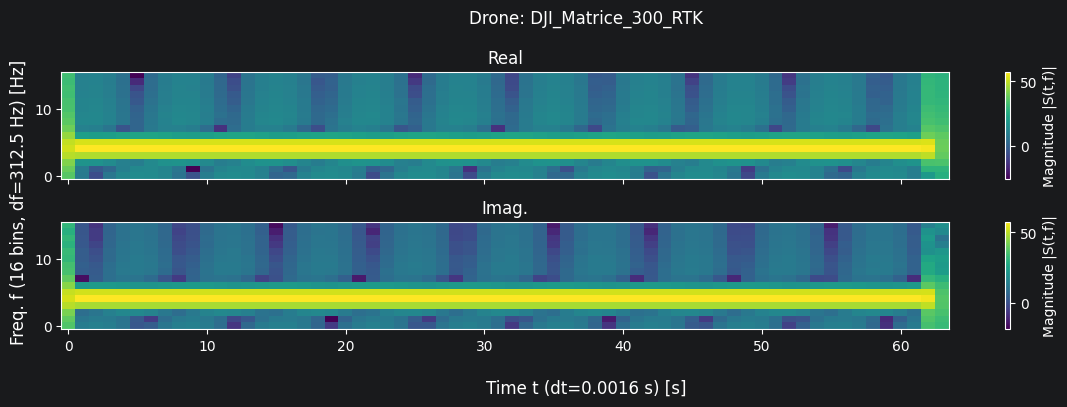

In [9]:
PROJECT_ROOT = Path().cwd().parent
type = "time_domain"
load_path = PROJECT_ROOT / "Data" / "Datasets" / type / "training_dataset.pkl"

md = DatasetMetadata.create_from_path(load_path)
synt_dataset = SyntheticDataFileLoader(dataset_metadata=md)

obj = synt_dataset.peek_sample(index=6000)

td_data_parser = TimeDomainDataParser()
signal, label, misc_data = td_data_parser.extract_training_data_and_label(obj)
td_data_parser.plot_drone_spectrogram(signal, misc_data, nperseg=32, noverlap=16)

In [10]:
parsed_signal, label, misc_data = td_data_parser.parse_data_object(obj)
parsed_signal, label, misc_data

(tensor([ 7.0232,  3.6288,  2.5064,  2.2650,  1.9713,  2.2520,  2.4046,  3.3200,
          6.2894, 89.2546]),
 1,
 DataRequest(request_name='label=DJI_Matrice_300_RTK', drone=Drone(name='DJI_Matrice_300_RTK', N=2, L_1=0.05, L_2=0.2665, f_rot=70), radar=Radar(λ=0.02998, f_c=9999748432.288193), context=Context(R=1520.0568606927932, V_rad=29.999718426099054, θ=0.3926806281264518, Φ_p=0.6228512920884408, A_r=7.299403777764336, snr=np.int64(25), t_start=0, t_stop=0.1, dt=0.0001), noise_model=<Data.noise_models.AdditiveWhiteGaussianNoise object at 0x000001B200591040>, sample_size=70))

In [11]:
PROJECT_ROOT = Path().cwd().parent
type = "frequency_domain"
load_path = PROJECT_ROOT / "Data" / "Datasets" / type / "training_dataset.pkl"

md = DatasetMetadata.create_from_path(load_path)
synt_dataset = SyntheticDataFileLoader(dataset_metadata=md)

obj = synt_dataset.peek_sample(index=6000)

td_data_parser = FrequencyDomainDataParser()
signal, label, misc_data = td_data_parser.parse_data_object(obj, bin_size=1, return_mag=False)
print(signal.shape)

torch.Size([2, 16, 64])


## Training pipeline

In [3]:
from abc import ABC, abstractmethod

class AbstractTrainer(ABC):
    def __init__(self, training_path, validating_path, testing_path, criterion):
        self.trainset = SyntheticTimeDomainRadarDataset(training_path)
        self.valset = SyntheticTimeDomainRadarDataset(validating_path, mean=self.trainset.mean, std=self.trainset.std)
        self.testset = SyntheticTimeDomainRadarDataset(testing_path, mean=self.trainset.mean, std=self.trainset.std)
        self.criterion = criterion

    @abstractmethod
    def train_model(self, config, model):
        pass

    @abstractmethod
    def test_model(self, model):
        pass

class TrainerForHiperparameterSearch(AbstractTrainer):
    def __init__(self, training_path, validating_path, testing_path , criterion):
        super().__init__(training_path, validating_path, testing_path, criterion)

    def train_model(self, config, model_class: nn.Module):
        net = model_class(config["l1"], config["l2"])
        device = config["device"]

        net = net.to(device)
        if torch.cuda.device_count() > 1:
            net = nn.DataParallel(net)

        optimizer = SGD(net.parameters(), lr=config["lr"], momentum=0.9)

        checkpoint = tune.get_checkpoint()
        if checkpoint:
            with checkpoint.as_directory() as checkpoint_dir:
                checkpoint_path = Path(checkpoint_dir) / "checkpoint.pt"
                checkpoint_state = torch.load(checkpoint_path)
                start_epoch = checkpoint_state["epoch"]
                net.load_state_dict(checkpoint_state["net_state_dict"])
                optimizer.load_state_dict(checkpoint_state["optimizer_state_dict"])
        else:
            start_epoch = 0

        trainloader = DataLoader(self.trainset, batch_size=int(config["batch_size"]), shuffle=True)
        valloader = DataLoader(self.valset, batch_size=int(config["batch_size"]), shuffle=True)

        for epoch in range(start_epoch, config['epochs']):
            running_loss = 0.0
            epoch_steps = 0
            for i, data in enumerate(trainloader, 0):
                inputs, labels = data
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()

                outputs = net(inputs)
                loss = self.criterion(outputs, labels)
                loss.backward()
                optimizer.step()


                epoch_steps += 1
                # running_loss += loss.item()
                # if i % 2000 == 1999:
                #     print(
                #         "[%d, %5d] loss: %.3f"
                #         % (epoch + 1, i + 1, running_loss / epoch_steps)
                #     )
                #     running_loss = 0.0

            val_loss = 0.0
            val_steps = 0
            total = 0
            correct = 0
            for i, data in enumerate(valloader, 0):
                with torch.no_grad():
                    inputs, labels = data
                    inputs, labels = inputs.to(device), labels.to(device)

                    outputs = net(inputs)
                    _, predicted = torch.max(outputs.data, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

                    loss = self.criterion(outputs, labels)
                    val_loss += loss.cpu().numpy()
                    val_steps += 1

            checkpoint_data = {
                "epoch": epoch,
                "net_state_dict": net.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
            }
            with tempfile.TemporaryDirectory() as checkpoint_dir:
                checkpoint_path = Path(checkpoint_dir) / "checkpoint.pt"
                torch.save(checkpoint_data, checkpoint_path)

                checkpoint = Checkpoint.from_directory(checkpoint_dir)
                tune.report(
                    {"loss": val_loss / val_steps, "accuracy": correct / total},
                    checkpoint=checkpoint,
                )

        return net

    def test_model(self, model):
        testloader = DataLoader(self.testset, batch_size=32, shuffle=True)

        model.eval()
        val_loss = 0.0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze(-1)
                probs = torch.sigmoid(outputs)
                preds = (probs > 0.5).float()

                loss = self.criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)

                all_preds.append(preds)
                all_labels.append(labels)


        all_preds = torch.cat(all_preds)
        all_labels = torch.cat(all_labels)
        results = self.calculate_metrics(all_labels,all_preds)

        return results

    def calculate_metrics(self, labels, predictions):

        tn, fp, fn, tp = confusion_matrix(labels, predictions)
        accuracy = accuracy_score(labels, predictions)
        balanced_acc = balanced_accuracy_score(labels, predictions)
        precision = precision_score(labels, predictions, zero_division=0)
        recall = recall_score(labels, predictions, zero_division=0)
        f1 = f1_score(labels, predictions, zero_division=0)

        return {
            'accuracy': accuracy,
            'balanced_accuracy': balanced_acc,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'confusion_matrix': {'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn}
        }

class TrainerForModelStatistics(AbstractTrainer):
    def __init__(self, training_path, validating_path, testing_path, criterion):
        super().__init__(training_path, validating_path, testing_path, criterion)

    def load_model_from_ray_results(self, results, model):
        config = results.config

        model = model(l1=config["l1"], l2=config["l2"])

        # Step 3: Load checkpoint and restore weights
        with config.checkpoint.as_directory() as checkpoint_dir:
            state_dict = torch.load(os.path.join(checkpoint_dir, "checkpoint.pt"))[0]  # [0] for model_state
        model.load_state_dict(state_dict)


    def load_entire_model(self, model):
        self.model = model



In [4]:
def l1_normalize_1d(x):
    return normalize(x, p=1, dim=0)

def l2_normalize_1d(x):
    return normalize(x, dim=0)

In [5]:
config = {
    "l1": tune.choice([2**i for i in range(1,11)]),
    "l2": tune.choice([2**i for i in range(1,11)]),
    "lr": tune.loguniform(1e-4, 1e-1),
    "batch_size": tune.choice([2, 4, 8, 16]),
    "device": "cpu",
    'epochs' : 100
}

max_num_epochs = 100
num_trials =  100
scheduler = ASHAScheduler(
    max_t=max_num_epochs,
    grace_period=1,
    reduction_factor=2,
)

cpus_per_trial = 4
gpus_per_trial = 0

PROJECT_ROOT = Path().cwd().parent
training_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "training_dataset.pkl"
validating_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "validating_dataset.pkl"
testing_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "testing_dataset.pkl"

trainer = TrainerForHiperparameterSearch(
    training_path=training_path,
    validating_path=validating_path,
    testing_path=testing_path,
    criterion = nn.CrossEntropyLoss()
)

tuner = tune.Tuner(
    tune.with_resources(
        tune.with_parameters(trainer.train_model, model_class=ClassicalNeuralNetwork),
        resources={"cpu": cpus_per_trial, "gpu": gpus_per_trial}
    ),
    tune_config=tune.TuneConfig(
        metric="loss",
        mode="min",
        scheduler=scheduler,
        num_samples=num_trials,
    ),
    param_space=config,
)
results = tuner.fit()

2026-04-07 18:20:58,810	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to 'C:/Users/adria/ray_results/train_model_2026-04-07_18-01-25' in 0.2121s.
2026-04-07 18:20:58,839	INFO tune.py:1041 -- Total run time: 1173.08 seconds (1172.58 seconds for the tuning loop).


### Classical Neural Network

In [65]:
batch_size = 32
qubit_size = 10

PROJECT_ROOT = Path().cwd().parent
training_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "training_dataset.pkl"
validating_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "validating_dataset.pkl"

training_data = SyntheticTimeDomainRadarDataset(training_path)
validating_data = SyntheticTimeDomainRadarDataset(validating_path, mean=training_data.mean, std=training_data.std)
train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
validating_dataloader = DataLoader(validating_data, batch_size=batch_size, shuffle=True)

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
model = ClassicalNeuralNetwork().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

trainer = TrainerForHiperparameterSearch(
    training_dataloader=train_dataloader,
    validating_dataloader=validating_dataloader,
    testing_dataloader=None,
    criterion=criterion
)

epochs = 1000
accuracy_array=[]
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    trainer.train()
    acc = trainer.test()
    accuracy_array.append(acc)
print("Done!")

Epoch 1
-------------------------------
loss: 1.113516  [   32/ 1470]
Test Error: 
 Accuracy: 33.3%, Avg loss: 1.098572 

Epoch 2
-------------------------------
loss: 1.105319  [   32/ 1470]
Test Error: 
 Accuracy: 33.3%, Avg loss: 1.094454 

Epoch 3
-------------------------------
loss: 1.098440  [   32/ 1470]
Test Error: 
 Accuracy: 32.4%, Avg loss: 1.090688 

Epoch 4
-------------------------------
loss: 1.093482  [   32/ 1470]
Test Error: 
 Accuracy: 33.3%, Avg loss: 1.086011 

Epoch 5
-------------------------------
loss: 1.090539  [   32/ 1470]
Test Error: 
 Accuracy: 33.3%, Avg loss: 1.084751 

Epoch 6
-------------------------------
loss: 1.074417  [   32/ 1470]
Test Error: 
 Accuracy: 33.3%, Avg loss: 1.081803 

Epoch 7
-------------------------------
loss: 1.071757  [   32/ 1470]
Test Error: 
 Accuracy: 33.3%, Avg loss: 1.077505 

Epoch 8
-------------------------------
loss: 1.064390  [   32/ 1470]
Test Error: 
 Accuracy: 33.3%, Avg loss: 1.071983 

Epoch 9
----------------

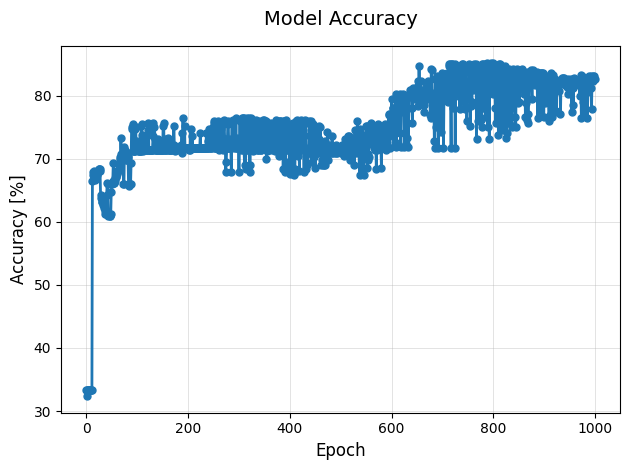

In [68]:
plt.plot(accuracy_array, marker='o', linestyle='-', color='#1f77b4', linewidth=2, markersize=5)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy", fontsize=14, pad=15)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy [%]", fontsize=12)
plt.grid()
plt.tight_layout()
plt.show()

### Quantum Neural Network

In [13]:
batch_size = 64
num_qubits = 10

PROJECT_ROOT = Path().cwd().parent
training_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "training_dataset.pkl"
validating_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "validating_dataset.pkl"

training_data = SyntheticTimeDomainRadarDataset(training_path)
validating_data = SyntheticTimeDomainRadarDataset(validating_path, mean=training_data.mean, std=training_data.std)

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
validating_dataloader = DataLoader(validating_data, batch_size=64, shuffle=True)

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
quantum_model = QuantumNeuralNetwork(num_qubits).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(quantum_model.parameters(), lr=1e-3)

trainer = TrainerForHiperparameterSearch(
    training_dataloader=train_dataloader,
    validating_dataloader=validating_dataloader,
    testing_dataloader=None,
    loss_fn=criterion,
)

epochs = 10
accuracy_array=[]
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    trainer.train()
    acc = trainer.test()
    accuracy_array.append(acc)
print("Done!")

Epoch 1
-------------------------------
loss: 1.802852  [   64/ 4620]
Test Error: 
 Accuracy: 15.5%, Avg loss: 1.795701 

Epoch 2
-------------------------------
loss: 1.784019  [   64/ 4620]
Test Error: 
 Accuracy: 15.5%, Avg loss: 1.795918 

Epoch 3
-------------------------------
loss: 1.789067  [   64/ 4620]
Test Error: 
 Accuracy: 15.5%, Avg loss: 1.795346 

Epoch 4
-------------------------------
loss: 1.792531  [   64/ 4620]
Test Error: 
 Accuracy: 15.5%, Avg loss: 1.795292 

Epoch 5
-------------------------------
loss: 1.789393  [   64/ 4620]


KeyboardInterrupt: 